In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.shape

(404290, 6)

In [6]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [12]:
df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='str')

In [14]:
df['q1_len']=df['question1'].str.len()
df['q2_len']=df['question2'].str.len()


In [18]:
df['q1_words']=df['question1'].apply(
    lambda x:len(str(x).split())
)
df['q2_words']=df['question2'].apply(
    lambda x:len(str(x).split())
)

In [19]:
np.mean(df['q1_len'])

np.float64(59.53699723216428)

In [20]:
x=np.array([1,2,3])

In [23]:
np.mean(df['q1_words'])

np.float64(10.942256367382576)

In [24]:
np.sqrt(df['q1_len'])

0         8.124038
1         7.141428
2         8.544004
3         7.071068
4         8.717798
            ...   
404285    9.219544
404286    6.403124
404287    4.123106
404288    9.695360
404289    6.082763
Name: q1_len, Length: 404287, dtype: float64

In [25]:
np.log(df['q1_len'])

0         4.189655
1         3.931826
2         4.290459
3         3.912023
4         4.330733
            ...   
404285    4.442651
404286    3.713572
404287    2.833213
404288    4.543295
404289    3.610918
Name: q1_len, Length: 404287, dtype: float64

In [26]:
np.min(df['q1_len'])

1

In [27]:
np.max(df['q1_len'])

623

In [28]:
np.std(df['q1_words'])

5.428805306785254

In [29]:
np.median(df['q1_len'])

np.float64(52.0)

In [30]:
import matplotlib.pyplot as plt

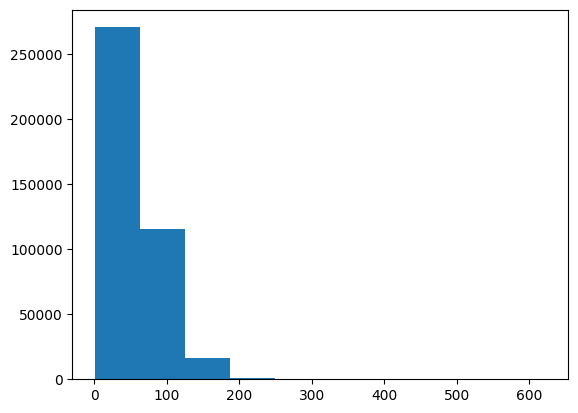

In [31]:
plt.hist(df['q1_len'])
plt.show()

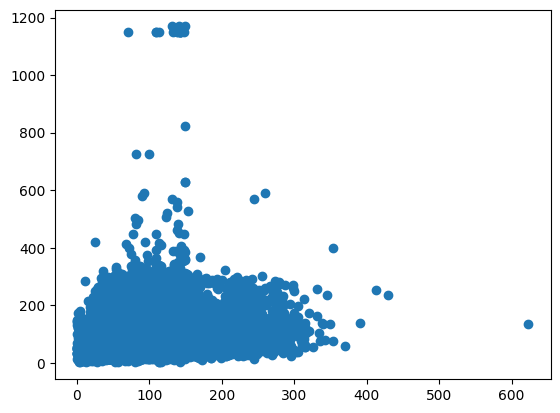

In [32]:
plt.scatter(df['q1_len'],df['q2_len'])
plt.show()

In [33]:
import seaborn as sns

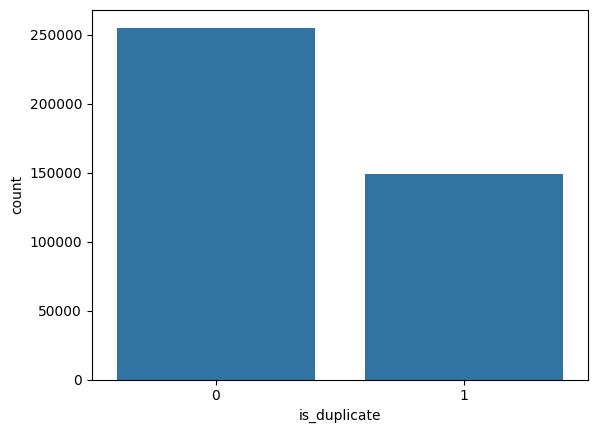

In [35]:
sns.countplot(x=df['is_duplicate'])
plt.show()

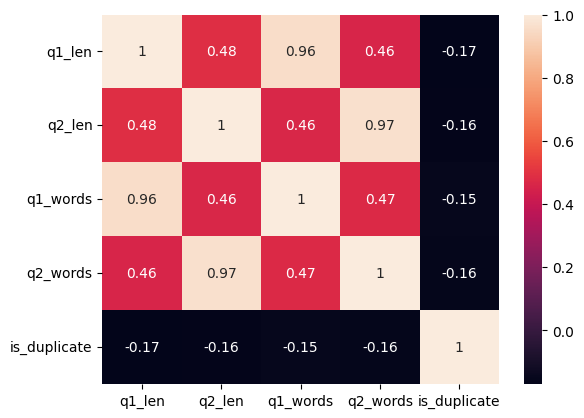

In [40]:
cols=[
'q1_len',
'q2_len',
'q1_words',
'q2_words',
'is_duplicate'
]

sns.heatmap(
df[cols].corr(),
annot=True
)
plt.show()

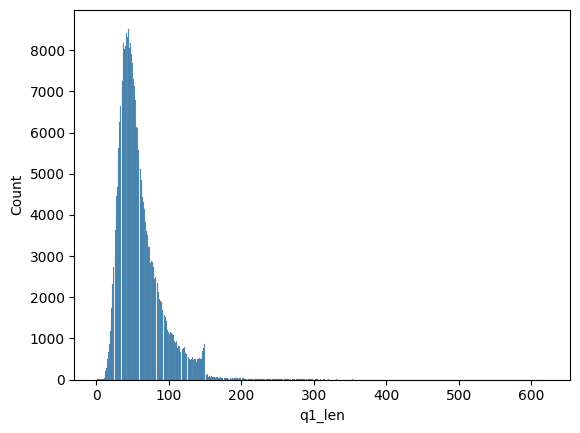

In [43]:
sns.histplot(df['q1_len'])
plt.show()

In [44]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [45]:
import nltk

In [46]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dorea\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

Test Preprocessing

In [47]:
from nltk.corpus import stopwords
stop=stopwords.words('english')

In [48]:
def clean_text(text):

 words=[]

 for word in text.split():

   if word not in stop:

      words.append(word)

 return " ".join(words)

In [51]:
df['question1']=df['question1'].apply(
clean_text
)

In [52]:
df['question2']=df['question2'].apply(
clean_text
)

ML

In [53]:
from sklearn.model_selection import train_test_split

In [56]:
x=df[['q1_len','q2_len','q1_words','q2_words']]
y=df['is_duplicate']
X_train,X_test,y_train,y_test=train_test_split(
x,
y,
test_size=0.2,
random_state=42
)

In [57]:
X_train.shape
X_test.shape

(80858, 4)

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [65]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.7 MB/s eta 0:00:38
   ---------------------------------------- 1.0/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.6/101.7 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 2.1/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 2.6/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.1/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.7/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.2/101.7 MB 2.5 MB/s eta 0:00:40
   - -------------------------------------- 4.7/101.7 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 5.2/101.7 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 5.8/101.7 MB 2.5 MB/s eta 0:00:38


In [66]:
from xgboost import XGBClassifier

In [67]:
model=XGBClassifier(
    random_state=42
)

In [68]:
model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [69]:
pred = model.predict(
    X_test
)

In [70]:
pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [72]:
accuracy_score(
    y_test,
    pred
)

0.6516485690964406

In [73]:
precision_score(
    y_test,
    pred
)

0.5536992840095465

In [74]:
recall_score(
    y_test,
    pred
)

0.2877447036739072

In [75]:
f1_score(
    y_test,
    pred
)

0.3786919598544171

In [76]:
print(
classification_report(
y_test,
pred
)
)

              precision    recall  f1-score   support

           0       0.67      0.86      0.76     51026
           1       0.55      0.29      0.38     29832

    accuracy                           0.65     80858
   macro avg       0.61      0.58      0.57     80858
weighted avg       0.63      0.65      0.62     80858



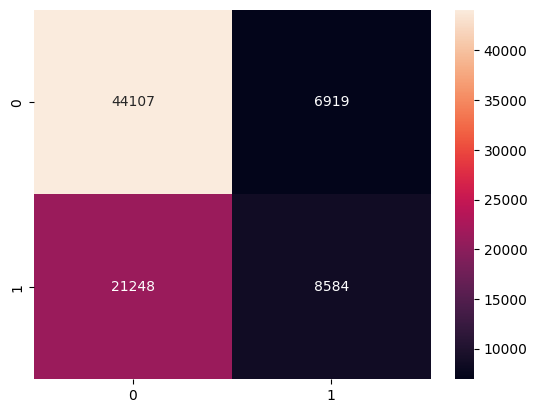

In [78]:
import seaborn as sns

sns.heatmap(
confusion_matrix(
y_test,
pred
),
annot=True,
fmt='d'
)
plt.show()

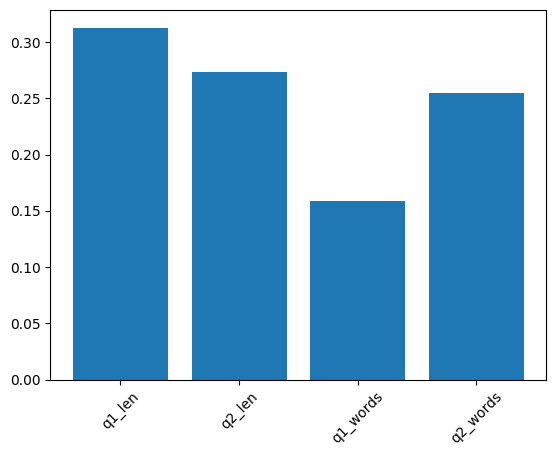

In [80]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

cols = x.columns

plt.bar(
cols,
importance
)

plt.xticks(rotation=45)

plt.show()

In [81]:
from sklearn.metrics import accuracy_score

accuracy_score(
y_test,
pred
)

0.6516485690964406

In [2]:
pip install fuzzywuzzy

In [3]:
from fuzzywuzzy import fuzz

c:\Users\dorea\anaconda\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [4]:
q1 = "How to learn Python?"

q2 = "Best way to learn Python?"

In [5]:
fuzz.ratio(
q1,
q2
)

80

In [6]:
df['fuzz_ratio']=df.apply(
lambda x:
fuzz.ratio(
str(x['question1']),
str(x['question2'])
),
axis=1
)

NameError: name 'df' is not defined

In [ ]:
df[['question1',
'question2',
'fuzz_ratio']].head()

,question1,question2,fuzz_ratio
0,What step step guide invest share market india?,What step step guide invest share market?,93
1,What story Kohinoor (Koh-i-Noor) Diamond?,What would happen Indian government stole Kohi...,64
2,How I increase speed internet connection using...,How Internet speed increased hacking DNS?,50
3,Why I mentally lonely? How I solve it?,Find remainder [math]23^{24}[/math] divided 24...,9
4,"Which one dissolve water quikly sugar, salt, m...",Which fish would survive salt water?,34


In [ ]:
df['token_sort']=df.apply(
lambda x:
fuzz.token_sort_ratio(
str(x['question1']),
str(x['question2'])
),
axis=1
)

In [ ]:
df['token_set']=df.apply(
lambda x:
fuzz.token_set_ratio(
str(x['question1']),
str(x['question2'])
),
axis=1
)

In [ ]:
X=df[
[
'q1_len',
'q2_len',
'q1_words',
'q2_words',
'fuzz_ratio',
'token_sort',
'token_set'
]
]

y=df['is_duplicate']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
random_state=42
)

model.fit(
X_train,
y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(
y_test,
pred
)

0.7245788913898439

In [ ]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
pred
)
)


              precision    recall  f1-score   support

           0       0.77      0.80      0.78     51026
           1       0.63      0.60      0.62     29832

    accuracy                           0.72     80858
   macro avg       0.70      0.70      0.70     80858
weighted avg       0.72      0.72      0.72     80858



<Axes: >

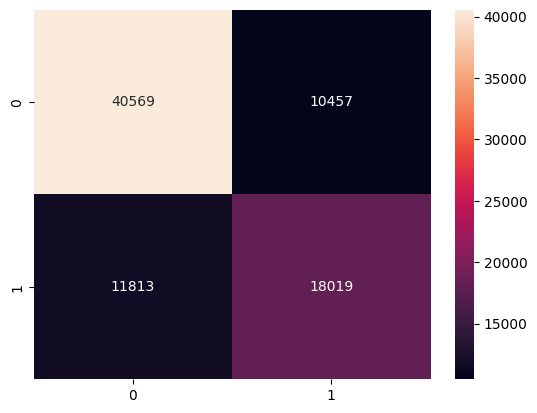

In [ ]:
from sklearn.metrics import confusion_matrix

sns.heatmap(
confusion_matrix(
y_test,
pred
),
annot=True,
fmt='d'
)

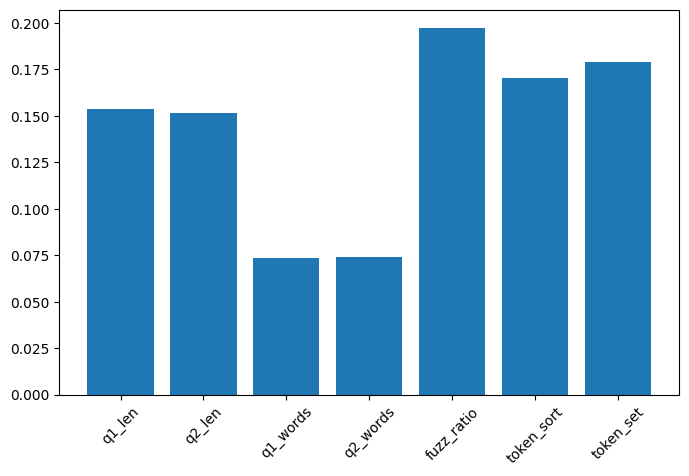

In [ ]:
importance=model.feature_importances_

cols=X.columns

plt.figure(figsize=(8,5))

plt.bar(
cols,
importance
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
import pickle

pickle.dump(
model,
open(
'model.pkl',
'wb'
)
)

In [ ]:
import os

os.listdir()

['model.pkl', 'quora.ipynb', 'train.csv']

In [ ]:
import streamlit as st
import pickle
from fuzzywuzzy import fuzz
import pandas as pd

model = pickle.load(
open(
'model.pkl',
'rb'
)
)

st.title(
"Quora Duplicate Question Detector"
)

q1 = st.text_input(
"Question 1"
)

q2 = st.text_input(
"Question 2"
)

if st.button(
"Predict"
):

    q1_len=len(q1)

    q2_len=len(q2)

    q1_words=len(
    q1.split()
    )

    q2_words=len(
    q2.split()
    )

    fuzz_ratio=fuzz.ratio(
    q1,
    q2
    )

    token_sort=fuzz.token_sort_ratio(
    q1,
    q2
    )

    token_set=fuzz.token_set_ratio(
    q1,
    q2
    )

    sample=pd.DataFrame({

    'q1_len':[q1_len],

    'q2_len':[q2_len],

    'q1_words':[q1_words],

    'q2_words':[q2_words],

    'fuzz_ratio':[fuzz_ratio],

    'token_sort':[token_sort],

    'token_set':[token_set]

    })

    pred=model.predict(
    sample
    )

    if pred[0]==1:

        st.success(
        "Duplicate Question"
        )

    else:

        st.error(
        "Not Duplicate"
        )

2026-05-21 20:50:44.365 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.910 
  command:

    streamlit run c:\Users\dorea\anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-21 20:50:44.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 20:50:44.926 Session state does not f